In [1]:
!pip install --upgrade openpyxl
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
mv = pd.read_excel("Sinemix IMDB IDs.xlsx")

# Dataset Overview

In [4]:
mv.head(6)

,FILM NAME,DIRECTOR,RELEASE YEAR,DECADE,GENRE,NUMBER OF OSCAR,IS THERE OSCAR AWARD,DURATION,IMDB SCORE,METASCORE,SINEMIX SCORE,LETTERBOXD,FILM SCORE,IMBD ID
0,Requiem for a Dream,Darren Aronofsky,2000,2000s,Drama,0,yok,102,83,68,100,82,86,tt0180093
1,Grave of the Fireflies,Isao Takahata,1988,1980s,Animation,0,yok,89,85,94,100,90,92,tt0095327
2,The Dark Knight,Christopher Nolan,2008,2000s,Superhero,2,var,152,90,84,99,90,92,tt0468569
3,The Lord of the Rings: The Return of the King,Peter Jackson,2003,2000s,Fantasy,11,var,201,89,94,99,90,93,tt0167260
4,Oldboy,Park Chan-Wook,2003,2000s,Drama,0,yok,120,84,77,99,88,89,tt0364569
5,Mulholland Drive,David Lynch,2001,2000s,Thriller,0,yok,147,85,100,93,88,90,tt0047396


In [5]:
mv.info()

<class 'pandas.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   FILM NAME             523 non-null    object
 1   DIRECTOR              523 non-null    str   
 2   RELEASE YEAR          523 non-null    int64 
 3   DECADE                523 non-null    str   
 4   GENRE                 523 non-null    str   
 5   NUMBER OF OSCAR       523 non-null    int64 
 6   IS THERE OSCAR AWARD  523 non-null    str   
 7   DURATION              523 non-null    int64 
 8   IMDB SCORE            523 non-null    int64 
 9   METASCORE             523 non-null    int64 
 10  SINEMIX SCORE         523 non-null    int64 
 11  LETTERBOXD            523 non-null    int64 
 12  FILM SCORE            523 non-null    int64 
 13  IMBD ID               523 non-null    str   
dtypes: int64(8), object(1), str(5)
memory usage: 76.9+ KB


In [6]:
mv.shape

(523, 14)

In [7]:
mv.describe(include='str')

,DIRECTOR,DECADE,GENRE,IS THERE OSCAR AWARD,IMBD ID
count,523,523,523,523,523
unique,302,8,17,2,523
top,Steven Spielberg,2010s,Drama,yok,tt0180093
freq,12,171,101,408,1


# Checking for Duplicate Rows

In [9]:
duplicates = mv[mv.duplicated()]

# Show results
if duplicates.empty:
    print("No duplicate rows found.")
else:
    print("Duplicate rows:")
    print(duplicates)

No duplicate rows found.


# Statistical Summary of Numerical Features

In [11]:
mv.describe().T  

,count,mean,std,min,25%,50%,75%,max
RELEASE YEAR,523.0,2004.309751,15.960549,1921.0,1998.0,2008.0,2016.0,2024.0
NUMBER OF OSCAR,523.0,0.554493,1.451117,0.0,0.0,0.0,0.0,11.0
DURATION,523.0,116.766730,28.011408,9.0,99.0,115.0,134.0,242.0
IMDB SCORE,523.0,76.460803,6.625729,53.0,72.0,77.0,81.0,93.0
METASCORE,523.0,72.478011,13.764612,30.0,64.0,74.0,83.0,100.0
SINEMIX SCORE,523.0,83.541109,5.801946,75.0,79.0,83.0,87.0,100.0
LETTERBOXD,523.0,75.208413,8.990873,44.0,70.0,76.0,82.0,94.0
FILM SCORE,523.0,77.856597,6.541680,58.0,74.0,79.0,82.0,93.0


# Outlier Detection with Box Plots

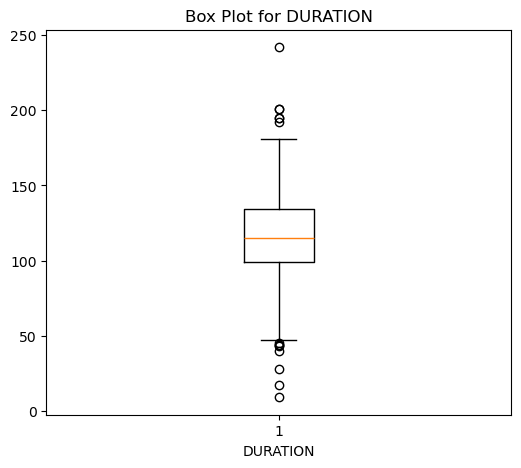

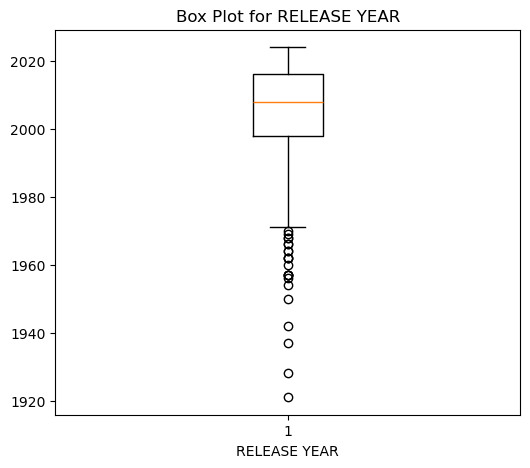

In [13]:
plt.figure(figsize=(6, 5))  # Figure size
plt.boxplot(mv['DURATION'].dropna(), vert=True)  # Vertical box plot
plt.title('Box Plot for DURATION')  # Chart title
plt.xlabel('DURATION')  # X axis label
plt.show()

plt.figure(figsize=(6, 5))  # Figure size
plt.boxplot(mv['RELEASE YEAR'].dropna(), vert=True)  # Vertical box plot
plt.title('Box Plot for RELEASE YEAR')  # Chart title
plt.xlabel('RELEASE YEAR')  # X axis label
plt.show()


# Outlier Analysis: Shortest and Longest Films

In [15]:
# Find the shortest film
shortest_film = mv.loc[mv['DURATION'].idxmin()]

# Find the longest film
longest_film = mv.loc[mv['DURATION'].idxmax()]

# Show the results
print("Shortest film:")
print(shortest_film)

print("\nLongest film:")
print(longest_film)

Shortest film:
FILM NAME                    Zima Blue
DIRECTOR                Robert Valley 
RELEASE YEAR                      2019
DECADE                           2010s
GENRE                        Animation
NUMBER OF OSCAR                      0
IS THERE OSCAR AWARD               yok
DURATION                             9
IMDB SCORE                          84
METASCORE                           90
SINEMIX SCORE                       95
LETTERBOXD                          84
FILM SCORE                          88
IMBD ID                      tt8566724
Name: 22, dtype: object

Longest film:
FILM NAME               Zack Snyder’s Justice League
DIRECTOR                                 Zack Snyder
RELEASE YEAR                                    2021
DECADE                                         2020s
GENRE                                      Superhero
NUMBER OF OSCAR                                    0
IS THERE OSCAR AWARD                             yok
DURATION                     

# Are There Any Null Rows?

In [17]:
mv.isnull().sum()

FILM NAME               0
DIRECTOR                0
RELEASE YEAR            0
DECADE                  0
GENRE                   0
NUMBER OF OSCAR         0
IS THERE OSCAR AWARD    0
DURATION                0
IMDB SCORE              0
METASCORE               0
SINEMIX SCORE           0
LETTERBOXD              0
FILM SCORE              0
IMBD ID                 0
dtype: int64

# Number of Films per Director

In [19]:
mv['DIRECTOR'].value_counts()

DIRECTOR
Steven Spielberg     12
Christopher Nolan    11
Tim Burton            7
Hayao Miyazaki        7
Ridley Scott          7
                     ..
Otto Bathurst         1
Marc Webb             1
Özer Kiziltan         1
Wes Ball              1
Fede Álvarez          1
Name: count, Length: 302, dtype: int64

# Number of Films per Genre

In [21]:
mv['GENRE'].value_counts()

GENRE
Drama        101
Sci-Fi        81
Animation     53
Horror        49
Superhero     38
Thriller      31
Fantasy       29
Comedy        27
Action        26
Adventure     23
Crime         17
War           14
Mystery       11
Romance       11
Biography      9
Musical        2
Western        1
Name: count, dtype: int64

# Pie Chart - Distribution of Film Genres

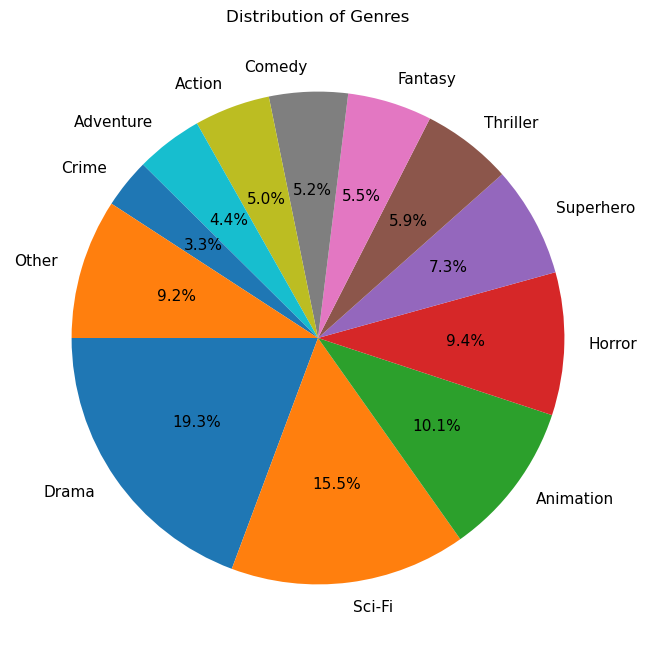

In [23]:
# Calculate the count for each genre
genre_counts = mv['GENRE'].value_counts()

# Group segments smaller than 3% into "Other"
threshold = 0.03 * genre_counts.sum()
other_count = genre_counts[genre_counts < threshold].sum()

# Filter segments that are 3% or larger
filtered_genre_counts = genre_counts[genre_counts >= threshold]

# Add "Other" category
if other_count > 0:
    filtered_genre_counts['Other'] = other_count

# Create a color palette
num_colors = len(filtered_genre_counts)
base_color = '#007bff'  
colors = [base_color]  
for i in range(1, num_colors):
    # Generate lighter shades for each segment
    color = plt.cm.Blues(i / num_colors)
    colors.append(color)

# Create the pie chart
plt.figure(figsize=(10, 8))
plt.pie(filtered_genre_counts, labels=filtered_genre_counts.index, autopct='%1.1f%%', startangle=180, textprops={'fontsize': 11})
plt.title('Distribution of Genres')
plt.show()

# Number of Films by Release Year

In [25]:
mv['RELEASE YEAR'].value_counts()

RELEASE YEAR
2009    24
2013    24
2019    23
2017    21
2018    19
        ..
1960     1
1987     1
1950     1
1928     1
1956     1
Name: count, Length: 68, dtype: int64

# Distribution of Films by Decade

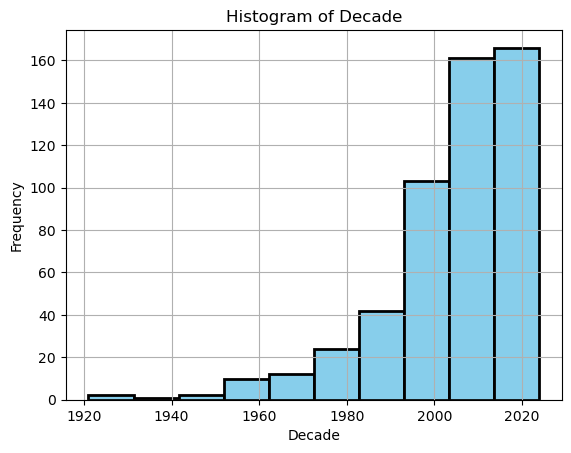

In [27]:
# Creating histogram
mv.hist(column='RELEASE YEAR', color="skyblue", edgecolor="black", linewidth=2)

# Title and display
plt.title('Histogram of Decade')
plt.xlabel('Decade')
plt.ylabel('Frequency')
plt.show()

# Film Score Distribution

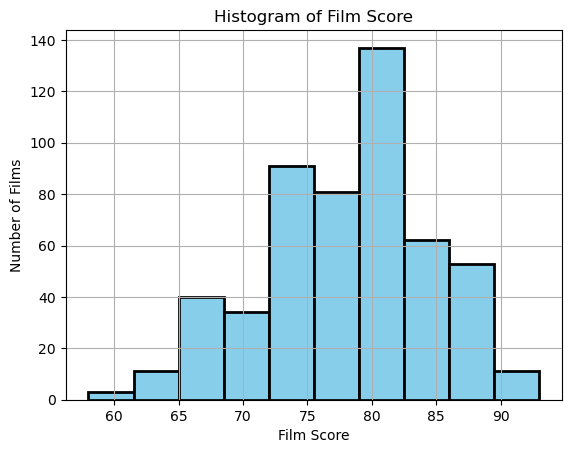

In [29]:
# Plotting histogram
mv.hist(column='FILM SCORE', color="skyblue", edgecolor="black", linewidth=2)

# Add title and legend
plt.title('Histogram of Film Score')
plt.xlabel('Film Score')
plt.ylabel('Number of Films')
plt.show()

# Correlation Analysis: Film Duration vs. Film Score

Correlation coefficient: 0.12


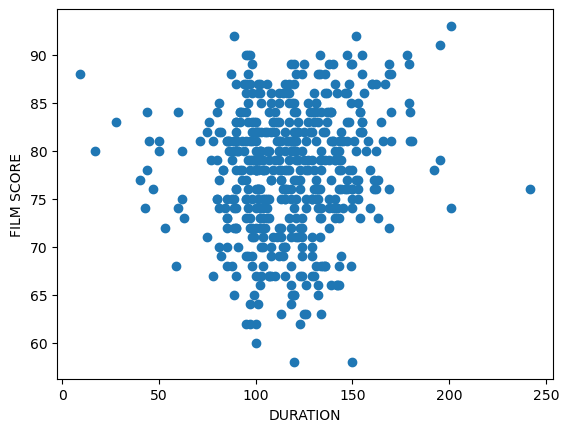

In [31]:
plt.scatter(mv['DURATION'], mv['FILM SCORE'])
plt.xlabel("DURATION")
plt.ylabel("FILM SCORE")
data = mv
correlation = data['DURATION'].corr(data['FILM SCORE'])
print(f'Correlation coefficient: {correlation:.2f}')

plt.show()

# a very weak positive relationship

# Correlation Analysis: Number of Oscar vs. Film Score

Correlation coefficient: 0.27


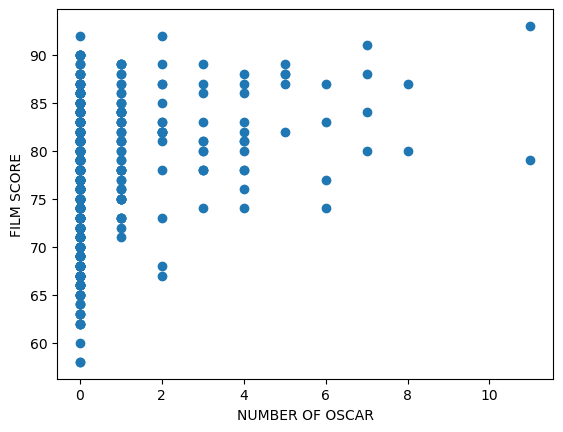

In [33]:
plt.scatter(mv['NUMBER OF OSCAR'], mv['FILM SCORE'])
plt.xlabel("NUMBER OF OSCAR")
plt.ylabel("FILM SCORE")
data = mv
correlation = data['NUMBER OF OSCAR'].corr(data['FILM SCORE'])
print(f'Correlation coefficient: {correlation:.2f}')

plt.show()

# weak positive relationship

# Directors with the Most Oscar-Winning Films

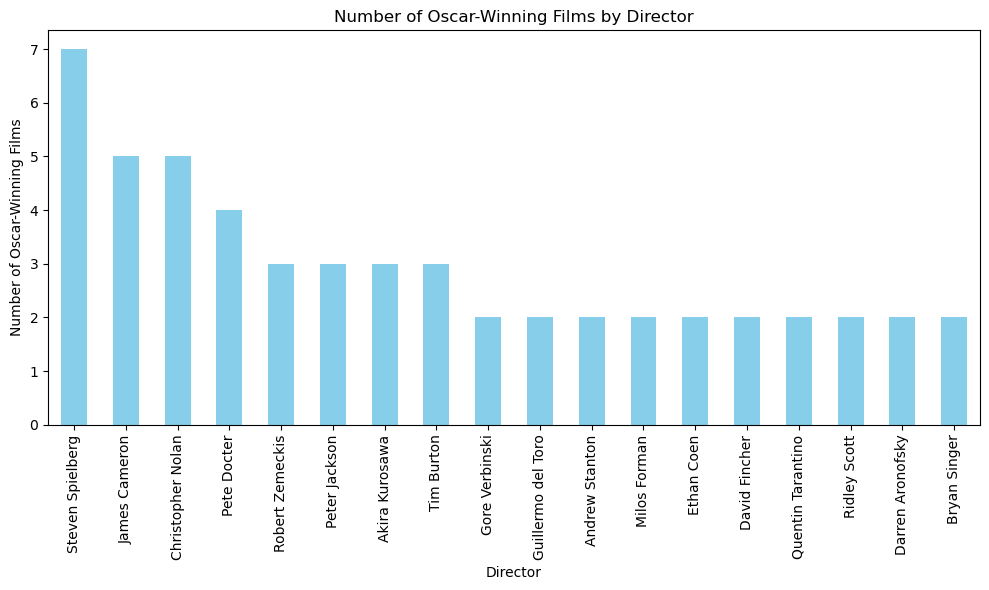

In [35]:
oscar_count = mv[mv['IS THERE OSCAR AWARD'] == 'var'].groupby('DIRECTOR').size()

# Filtering directors with more than 1 Oscar-winning film
oscar_count = oscar_count[oscar_count > 1]

# Sorting (descending)
oscar_count = oscar_count.sort_values(ascending=False)

# Creating bar chart
plt.figure(figsize=(10, 6))
oscar_count.plot(kind='bar', color='skyblue')
plt.title('Number of Oscar-Winning Films by Director')
plt.xlabel('Director')
plt.ylabel('Number of Oscar-Winning Films')
plt.xticks(rotation=90)
plt.tight_layout()  # To adjust layout
plt.show()

# Genre Distribution by Decade

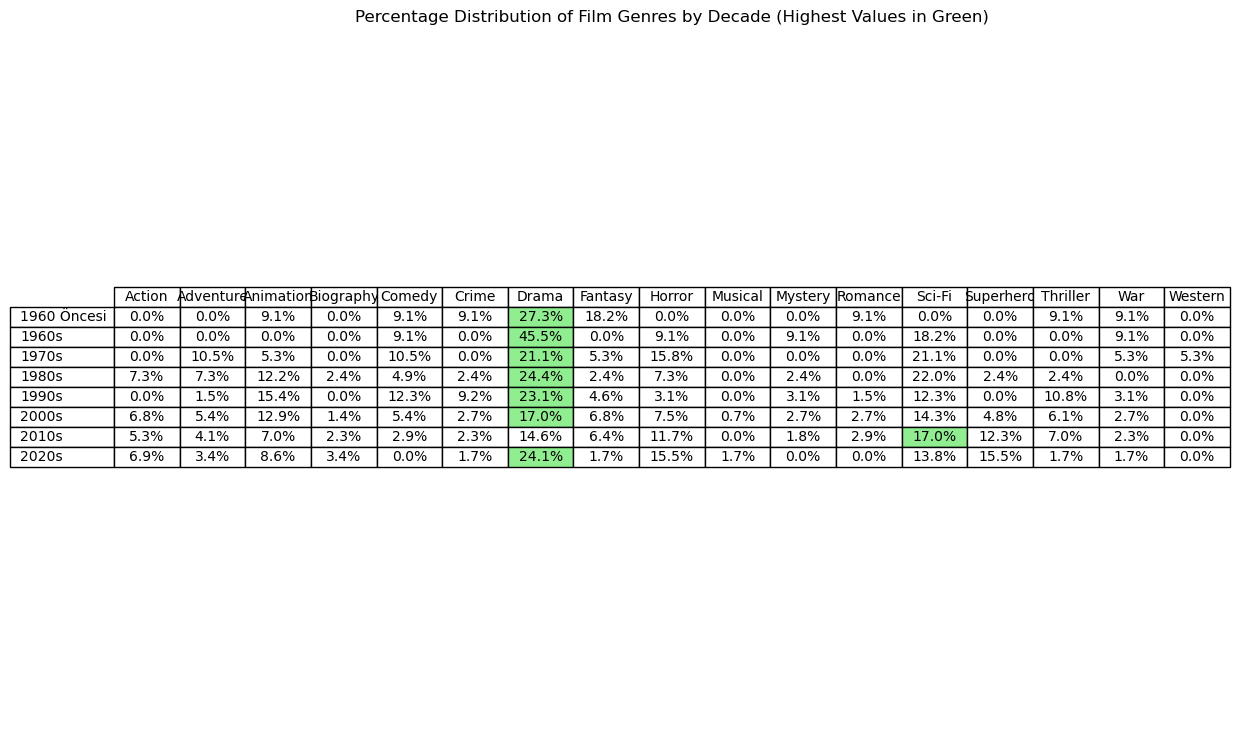

In [37]:
# Percentage distribution of film genres by decade

decade_genre_count = mv.groupby(['DECADE', 'GENRE']).size().reset_index(name='Count')

# Calculating percentages by decade
decade_genre_count['Percentage'] = decade_genre_count.groupby('DECADE')['Count'].transform(lambda x: x / x.sum() * 100)

# Converting percentages to pivot table
pivot_table = decade_genre_count.pivot(index='DECADE', columns='GENRE', values='Percentage').fillna(0)

# Adding percentage symbol
formatted_pivot_table = pivot_table.apply(lambda x: x.map("{:.1f}%".format))

# Highlighting the highest values in the table
plt.figure(figsize=(12, 9))
plt.axis('off')  # Hide axes

# Creating table cells
table = plt.table(cellText=formatted_pivot_table.values, 
                  colLabels=formatted_pivot_table.columns, 
                  rowLabels=formatted_pivot_table.index,
                  cellLoc='center', 
                  loc='center')

# Finding and highlighting the highest cells in green
for i, row in enumerate(pivot_table.iterrows()):
    max_col_index = row[1].idxmax()  # Find the highest value in the row
    max_col_pos = pivot_table.columns.get_loc(max_col_index)  # Get column position
    table[(i + 1, max_col_pos)].set_facecolor("lightgreen")  # Highlight the highest cell in green

# Adjusting table style
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.title('Percentage Distribution of Film Genres by Decade (Highest Values in Green)')
plt.show()

# Item Based Movie Recommendation System

In [39]:
import pandas as pd
import requests
from IPython.display import display, Image  # Imported to display visuals

class MovieRecommender:
    def __init__(self, dataframe, api_key):
        self.dataframe = dataframe
        self.api_key = api_key

    def get_poster_url(self, imdb_id):
        # Retrieves the poster URL via OMDb API
        url = f"http://www.omdbapi.com/?i={imdb_id}&apikey={self.api_key}"
        response = requests.get(url)
        data = response.json()
        return data.get("Poster", "Poster not found")

    def recommend(self, director=None, genre=None, decade=None, 
                  oscar_winner=None, min_duration=None, 
                  max_duration=None, min_film_score=None, 
                  max_film_score=None):
        
        # Start with the entire dataset as recommendations
        recommendations = self.dataframe
        
        # Filtering
        if director:
            recommendations = recommendations[recommendations['DIRECTOR'].str.contains(director, case=False)]
        
        if genre:
            recommendations = recommendations[recommendations['GENRE'].str.contains(genre, case=False)]
        
        if decade:
            recommendations = recommendations[recommendations['DECADE'] == decade]
        
        if oscar_winner is not None:
            recommendations = recommendations[recommendations['IS THERE OSCAR AWARD'] == oscar_winner]
        
        if min_duration is not None:
            recommendations = recommendations[recommendations['DURATION'] >= min_duration]
        
        if max_duration is not None:
            recommendations = recommendations[recommendations['DURATION'] <= max_duration]
        
        if min_film_score is not None:
            recommendations = recommendations[recommendations['FILM SCORE'] >= min_film_score]
        
        if max_film_score is not None:
            recommendations = recommendations[recommendations['FILM SCORE'] <= max_film_score]

        # Sort by film score and get the top 5 films
        recommendations = recommendations.sort_values(by='FILM SCORE', ascending=False).head(5)

        # Add poster URL
        recommendations['POSTER_URL'] = recommendations['IMBD ID'].apply(self.get_poster_url)

        return recommendations

# Get input from the user
print("Movie recommendation system. Please enter the following criteria:")

director = input("Enter director name (e.g. Christopher Nolan, leave blank to skip): ")
genre = input("Enter genre (e.g. Drama, Sci-Fi, leave blank to skip): ")
decade = input("Enter decade (e.g. 1990s, leave blank to skip): ")
oscar_winner = input("Oscar winner? (yes/no, leave blank to skip): ")
min_duration = input("Enter minimum duration (minutes, leave blank to skip): ")
max_duration = input("Enter maximum duration (minutes, leave blank to skip): ")
min_film_score = input("Enter minimum film score (e.g. 75, leave blank to skip): ")
max_film_score = input("Enter maximum film score (e.g. 90, leave blank to skip): ")

# Convert non-empty values to appropriate data types
oscar_winner = 'var' if oscar_winner.lower() == 'yes' else 'yok' if oscar_winner.lower() == 'no' else None
min_duration = int(min_duration) if min_duration else None
max_duration = int(max_duration) if max_duration else None
min_film_score = int(min_film_score) if min_film_score else None
max_film_score = int(max_film_score) if max_film_score else None

# Create the movie recommendation system and get recommendations
api_key = "5a95555"  # Adding OMDb API key
recommender = MovieRecommender(mv, api_key)  # Using the mv dataset here
recommendations = recommender.recommend(director, genre, decade, 
                                        oscar_winner, min_duration, 
                                        max_duration, min_film_score, 
                                        max_film_score)

# Display recommendations
if recommendations.empty:
    print("\nNo films found matching the specified criteria.")
else:
    print("\nRecommended Films:")
    for index, row in recommendations.iterrows():
        print(f"Film: {row['FILM NAME']}")  # Film name only
        # Display visuals
        display(Image(url=row['POSTER_URL']))  # Display image with poster URL



Movie recommendation system. Please enter the following criteria:


Enter director name (e.g. Christopher Nolan, leave blank to skip):  Christopher Nolan
Enter genre (e.g. Drama, Sci-Fi, leave blank to skip):  Sci-Fi
Enter decade (e.g. 1990s, leave blank to skip):  2010s
Oscar winner? (yes/no, leave blank to skip):  yes
Enter minimum duration (minutes, leave blank to skip):  
Enter maximum duration (minutes, leave blank to skip):  
Enter minimum film score (e.g. 75, leave blank to skip):  
Enter maximum film score (e.g. 90, leave blank to skip):  



Recommended Films:
Film: Interstellar


Film: Inception
